In [6]:
# -------------------------------------------------------
# PCA on the Wine Dataset + Show Top Components per PC
# -------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------------------------------
# 1. Load the Wine dataset
# -------------------------------------------------------
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
print("Wine dataset (first 5 rows):")
print(df.head(), "\n")


Wine dataset (first 5 rows):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

Wine dataset (first 5 rows):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  

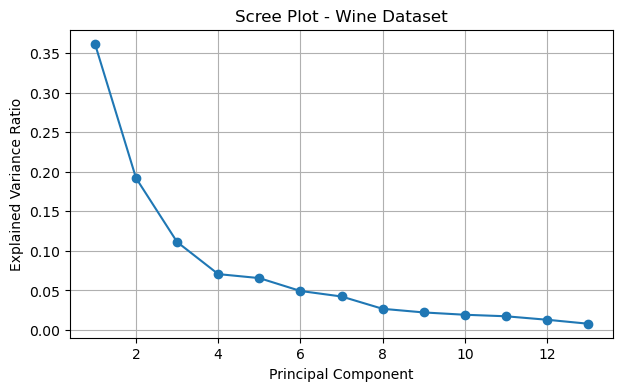

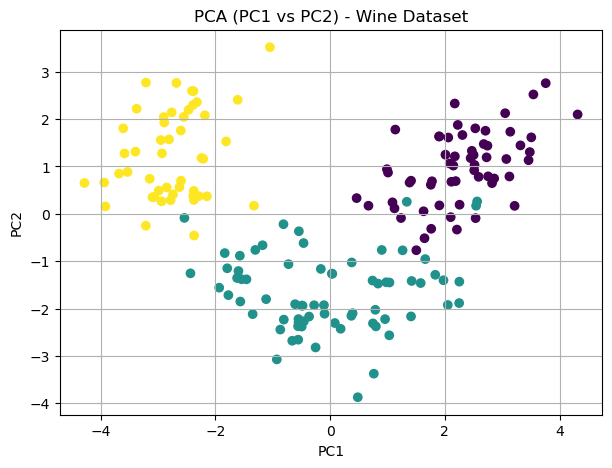

PCA Components (loadings):
       alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1   0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2   0.483652    0.224931  0.316069          -0.010591   0.299634   
PC3  -0.207383    0.089013  0.626224           0.612080   0.130757   
PC4  -0.017856    0.536890 -0.214176           0.060859  -0.351797   
PC5  -0.265664    0.035214 -0.143025           0.066103   0.727049   
PC6   0.213539    0.536814  0.154475          -0.100825   0.038144   
PC7  -0.056396    0.420524 -0.149171          -0.286969   0.322883   
PC8   0.396139    0.065827 -0.170260           0.427970  -0.156361   
PC9  -0.508619    0.075283  0.307694          -0.200449  -0.271403   
PC10  0.211605   -0.309080 -0.027125           0.052799   0.067870   
PC11 -0.225917    0.076486 -0.498691           0.479314   0.071289   
PC12 -0.266286    0.121696 -0.049622          -0.055743   0.062220   
PC13  0.014970    0.025964 -0.141218           0.091683   0.056

In [2]:
# -------------------------------------------------------
# PCA on the Wine Dataset + Show Top Components per PC
# -------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------------------------------------
# 1. Load the Wine dataset
# -------------------------------------------------------
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
print("Wine dataset (first 5 rows):")
print(df.head(), "\n")

# -------------------------------------------------------
# 2. Standardize
# -------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------------------------------
# 3. PCA (keep all components for analysis)
# -------------------------------------------------------
pca = PCA(n_components=len(feature_names))
X_pca = pca.fit_transform(X_scaled)

# -------------------------------------------------------
# 4. Show explained variance
# -------------------------------------------------------
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_, "\n")

# Scree Plot
plt.figure(figsize=(7,4))
plt.plot(range(1, len(feature_names)+1), pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot - Wine Dataset")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# 5. PCA scatter (first two PCs)
# -------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (PC1 vs PC2) - Wine Dataset")
plt.grid(True)
plt.show()

# -------------------------------------------------------
# 6. Top contributing features for each PC
# -------------------------------------------------------
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(len(feature_names))]
)

print("PCA Components (loadings):")
print(components_df, "\n")

# Show top 3 features for first 3 PCs
for i in range(3):
    print(f"Top contributing features for PC{i+1}:")
    print(components_df.iloc[i].abs().sort_values(ascending=False).head(3))
    print()


STEP 2 Output: Wine dataset (first 5 rows):
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_

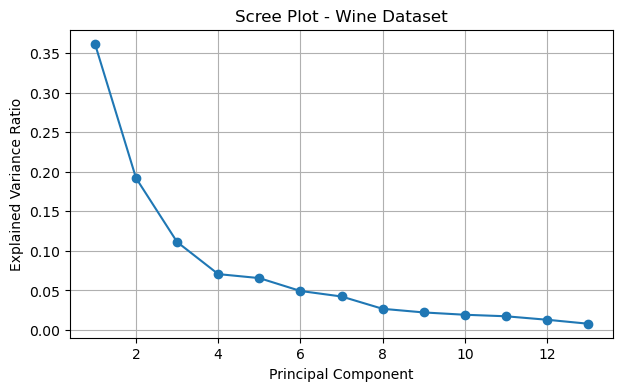

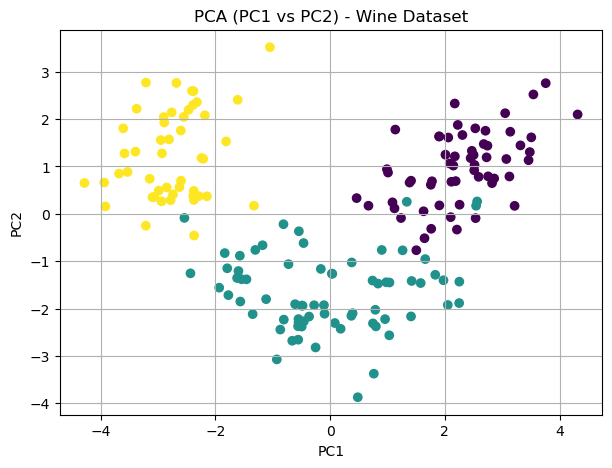

STEP 7 Output: PCA Component Loadings (table):
       alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1   0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2   0.483652    0.224931  0.316069          -0.010591   0.299634   
PC3  -0.207383    0.089013  0.626224           0.612080   0.130757   
PC4  -0.017856    0.536890 -0.214176           0.060859  -0.351797   
PC5  -0.265664    0.035214 -0.143025           0.066103   0.727049   
PC6   0.213539    0.536814  0.154475          -0.100825   0.038144   
PC7  -0.056396    0.420524 -0.149171          -0.286969   0.322883   
PC8   0.396139    0.065827 -0.170260           0.427970  -0.156361   
PC9  -0.508619    0.075283  0.307694          -0.200449  -0.271403   
PC10  0.211605   -0.309080 -0.027125           0.052799   0.067870   
PC11 -0.225917    0.076486 -0.498691           0.479314   0.071289   
PC12 -0.266286    0.121696 -0.049622          -0.055743   0.062220   
PC13  0.014970    0.025964 -0.141218       

In [3]:
# -------------------------------------------------------
# STEP 1: Import all required libraries
# -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# -------------------------------------------------------
# STEP 2: Load the built-in Wine dataset
# -------------------------------------------------------
wine = load_wine()                     # Load dataset
X = wine.data                          # Features
y = wine.target                        # Labels (target classes)
feature_names = wine.feature_names     # Names of input features

# Convert to dataframe for readability
df = pd.DataFrame(X, columns=feature_names)
print("STEP 2 Output: Wine dataset (first 5 rows):")
print(df.head(), "\n")


# -------------------------------------------------------
# STEP 3: Standardize the features
# PCA requires normalized data (mean=0, standard deviation=1)
# -------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("STEP 3 Output: Mean of scaled data:", X_scaled.mean())
print("             Std of scaled data :", X_scaled.std(), "\n")


# -------------------------------------------------------
# STEP 4: Apply PCA
# We keep ALL components to analyze the structure
# -------------------------------------------------------
pca = PCA(n_components=len(feature_names))
X_pca = pca.fit_transform(X_scaled)

print("STEP 4 Output: Shape of PCA result:", X_pca.shape, "\n")


# -------------------------------------------------------
# STEP 5: View explained variance ratio
# This tells us how much information each PC captures
# -------------------------------------------------------
print("STEP 5 Output: Explained Variance Ratio:")
print(pca.explained_variance_ratio_, "\n")

# Plot Scree Plot
plt.figure(figsize=(7,4))
plt.plot(range(1, len(feature_names)+1), pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot - Wine Dataset")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()


# -------------------------------------------------------
# STEP 6: Plot the first two principal components
# This shows how classes separate in reduced dimensions
# -------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.title("PCA (PC1 vs PC2) - Wine Dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


# -------------------------------------------------------
# STEP 7: Display PCA component loadings
# Each row = PC1, PC2, ..., PC13
# Each column = how much that feature contributes to PC
# -------------------------------------------------------
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(len(feature_names))]
)

print("STEP 7 Output: PCA Component Loadings (table):")
print(components_df, "\n")


# -------------------------------------------------------
# STEP 8: Show Top 3 contributing features for first 3 PCs
# Helps understand which features are most important in PCA
# -------------------------------------------------------
for i in range(3):
    print(f"STEP 8 Output: Top contributing features for PC{i+1}:")
    print(components_df.iloc[i].abs().sort_values(ascending=False).head(3))
    print()


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

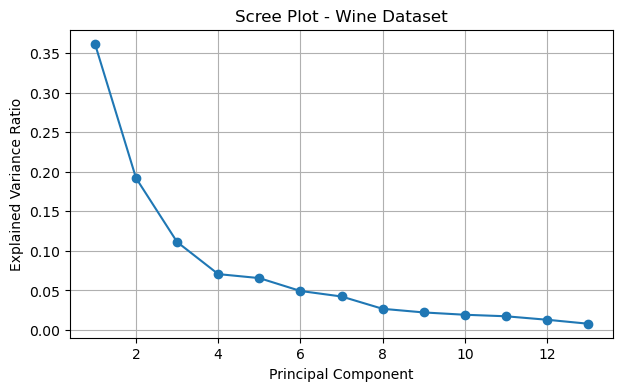

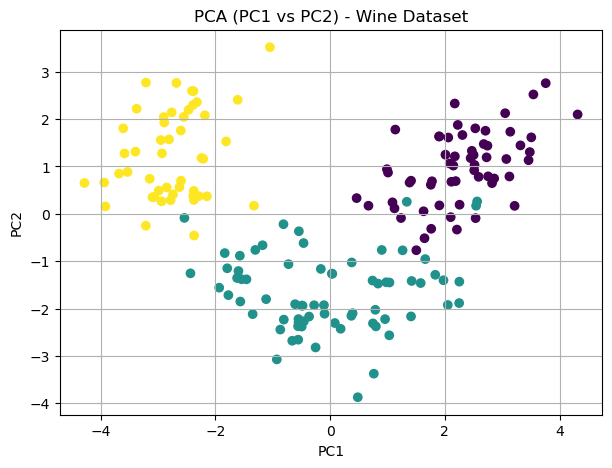

PCA Component Loadings:
       alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1   0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2   0.483652    0.224931  0.316069          -0.010591   0.299634   
PC3  -0.207383    0.089013  0.626224           0.612080   0.130757   
PC4  -0.017856    0.536890 -0.214176           0.060859  -0.351797   
PC5  -0.265664    0.035214 -0.143025           0.066103   0.727049   
PC6   0.213539    0.536814  0.154475          -0.100825   0.038144   
PC7  -0.056396    0.420524 -0.149171          -0.286969   0.322883   
PC8   0.396139    0.065827 -0.170260           0.427970  -0.156361   
PC9  -0.508619    0.075283  0.307694          -0.200449  -0.271403   
PC10  0.211605   -0.309080 -0.027125           0.052799   0.067870   
PC11 -0.225917    0.076486 -0.498691           0.479314   0.071289   
PC12 -0.266286    0.121696 -0.049622          -0.055743   0.062220   
PC13  0.014970    0.025964 -0.141218           0.091683   0.056774

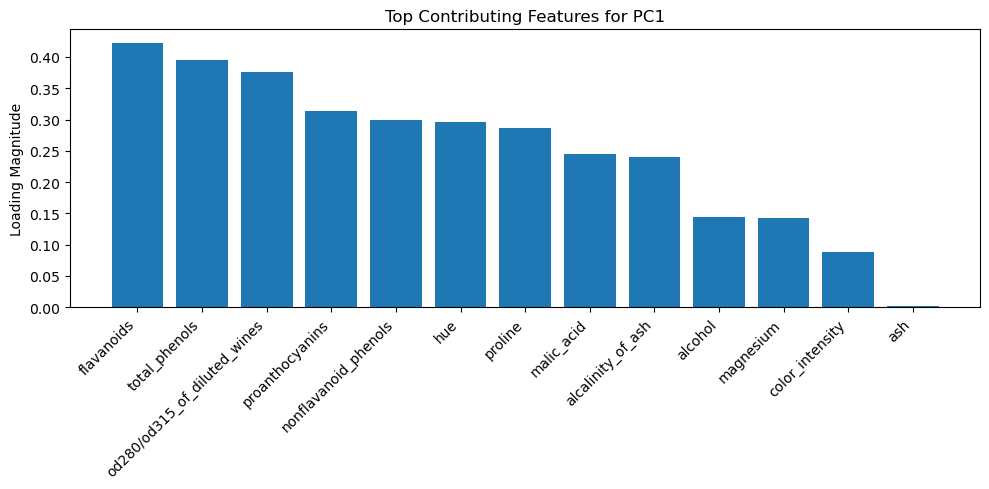

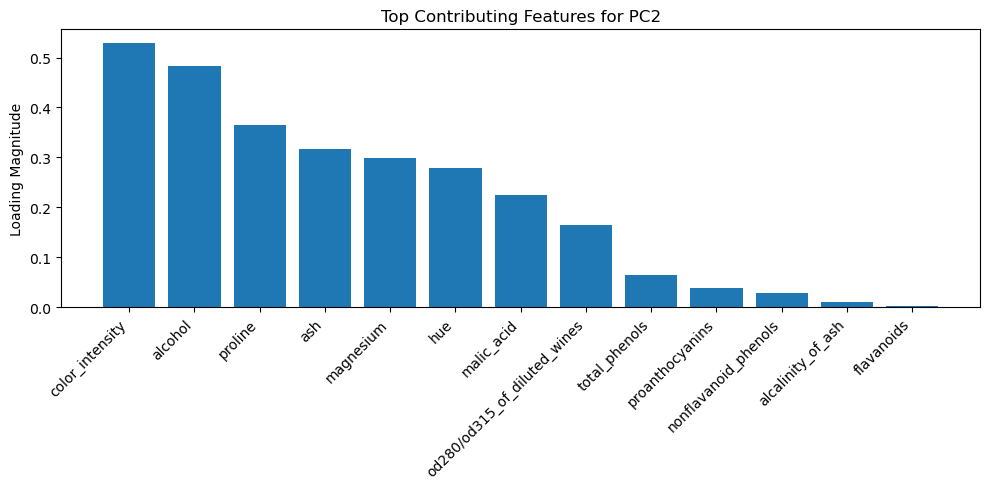

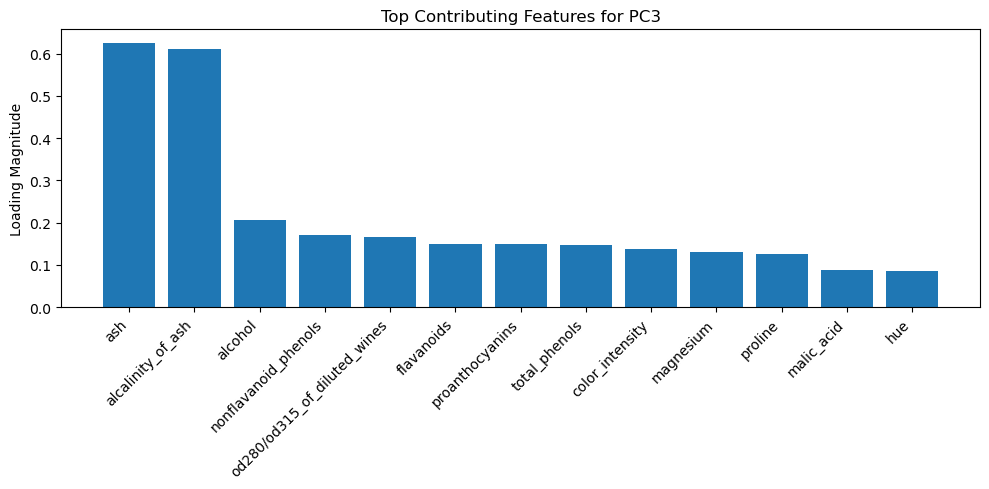

In [4]:
# -------------------------------------------------------
# STEP 1: Import all required libraries
# -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# -------------------------------------------------------
# STEP 2: Load the built-in Wine dataset
# -------------------------------------------------------
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
print(df.head())


# -------------------------------------------------------
# STEP 3: Standardize the features
# -------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# -------------------------------------------------------
# STEP 4: Apply PCA
# -------------------------------------------------------
pca = PCA(n_components=len(feature_names))
X_pca = pca.fit_transform(X_scaled)


# -------------------------------------------------------
# STEP 5: Scree Plot
# -------------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(range(1, len(feature_names)+1), pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot - Wine Dataset")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()


# -------------------------------------------------------
# STEP 6: PCA Scatter (PC1 vs PC2)
# -------------------------------------------------------
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (PC1 vs PC2) - Wine Dataset")
plt.grid(True)
plt.show()


# -------------------------------------------------------
# STEP 7: PCA Component Loadings
# -------------------------------------------------------
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=[f"PC{i+1}" for i in range(len(feature_names))]
)

print("PCA Component Loadings:")
print(components_df)


# -------------------------------------------------------
# STEP 8: BAR PLOTS for TOP COMPONENTS (PC1, PC2, PC3)
# -------------------------------------------------------

# Select first 3 PCs to plot
pcs_to_plot = [0, 1, 2]

for pc in pcs_to_plot:
    plt.figure(figsize=(10,5))
    
    # absolute values to show importance clearly
    loadings = components_df.iloc[pc].abs().sort_values(ascending=False)
    
    plt.bar(loadings.index, loadings.values)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Loading Magnitude")
    plt.title(f"Top Contributing Features for PC{pc+1}")
    plt.tight_layout()
    plt.show()


In [9]:
# Step 1: Import libraries
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Step 2: Load dataset
data = load_wine()
X = data.data
y = data.target

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 🔹 BEFORE PCA
# =========================

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_before = knn.predict(X_test_scaled)
acc_before = accuracy_score(y_test, y_pred_before)

print("Accuracy BEFORE PCA:", acc_before)


# =========================
# 🔹 AFTER PCA
# =========================

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Train again
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

y_pred_after = knn_pca.predict(X_test_pca)
acc_after = accuracy_score(y_test, y_pred_after)

print("Accuracy AFTER PCA:", acc_after)

Accuracy BEFORE PCA: 0.9629629629629629
Accuracy AFTER PCA: 0.9814814814814815
